In [1]:
import pandas as pd
from datasets import Horses
from utils import stratified_split

pd.set_option('display.float_format', '{:.2f}'.format)

/home/brambles/Documents/A-Py/Pone-Tagger/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data/image_data.csv')
df['tags'] = df['tags'].str.split('|')
print(len(df))

to_predict = (
    'female', 'male',
    'unicorn', 'pegasus', 'earth pony', 'alicorn',
    'simple background', 'monochrome',
    'clothes', 'wings', 'horn', 'chest fluff', 'ear fluff', 'hat', 'jewelry', 'food', 'foal',
    'looking at you', 'smiling', 'open mouth', 'blushing', 'sitting', 'raised hoof', 'eyes closed',
    'twilight sparkle', 'fluttershy', 'rainbow dash', 'pinkie pie', 'rarity', 'applejack'
)

ds = Horses(df, to_predict)
df['tags'] = ds.df['tags']
idx_train, y_train, idx_test, y_test = stratified_split(ds.df['tags'])

182736


In [3]:
from transformers import AutoModel
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
from torch import nn, Tensor
import torch
from utils import confusion_matrix

In [4]:
class Tagger(nn.Module):
    def __init__(self, cls_head: nn.Module):
        super().__init__()

        self.backbone: nn.Module = AutoModel.from_pretrained('facebook/dinov2-base')
        self.classifier = cls_head

        for layer in self.classifier:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')

    def forward(self, x):
        ViT_output = self.backbone(x)
        embeddings = ViT_output.last_hidden_state[:, 0]

        return self.classifier(embeddings)

    def train(self):
        super().train()
        self.backbone.eval()

head = nn.Sequential(
    nn.Linear(768, 256),
    nn.ReLU(True),
    nn.Dropout(0.3),
    nn.Linear(256, 128),
    nn.ReLU(True),
    nn.Dropout(0.3),
    nn.Linear(128, 30)
)

model = Tagger(head)

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 6303.27it/s]


In [5]:
epochs = 150
batch_size = 64
lr = 1e-4
weight_decay = 1e-3
alpha = 0.2
gamma = 0.4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [6]:
def pu_mlc_loss(logits: Tensor, labels: Tensor):
    temp = (alpha * logits.std(0, False)).clamp(1e-6, 1.0).detach()

    outputs = (logits / temp).sigmoid()
    log_pos_probs = outputs.clamp_min(1e-10).log() * labels

    num_p_rec = 1 / labels.sum(0)
    num_p_rec = torch.where(num_p_rec.isinf(), torch.zeros_like(num_p_rec), num_p_rec)
    num_u_rec = 1 / labels.shape[0]

    p_c = outputs.mean(0)
    u_loss = (num_u_rec * outputs.sum(0)).clamp_min(1e-10).log()
    p_loss = num_p_rec * log_pos_probs.sum(0)

    class_losses = p_c.pow(gamma).detach() * u_loss - p_loss

    return class_losses.sum()

def mixup_loss(x: Tensor, outputs: Tensor, y: Tensor, model):
    log_probs = outputs.sigmoid().clamp_min(1e-10).log()
    beta_dist = torch.distributions.Beta(0.2, 0.2)

    midpoint1 = int(x.shape[0] / 2)
    # This makes sure all partitions are of equal size
    midpoint2 = midpoint1 + (1 if x.shape[0] % 2 == 1 else 0)

    x1, x2 = x[:midpoint1], x[midpoint2:]
    y1, y2 = y[:midpoint1], y[midpoint2:]
    log_yh1, log_yh2 = log_probs[:midpoint1], log_probs[midpoint2:]

    idx_perm = torch.randperm(len(x1))
    x1_perm, log_yh_perm1 = x1[idx_perm], log_yh1[idx_perm]

    l = beta_dist.sample()

    x_mixed = l * x + (1 - l) * x[idx_perm]
    y_mixed = l * y + (1 - l) * y[idx_perm]

    return ((torch.sigmoid(model(x_mixed)).clamp(1e-10).log() - y_mixed.log()) ** 2).mean()


In [7]:
model.to(device)

optim = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

In [8]:
dl_train = DataLoader(
    Subset(ds, idx_train),
    batch_size=batch_size,
    pin_memory=True,
    num_workers=5,
    persistent_workers=True,
    shuffle=True
)

dl_test = DataLoader(
    Subset(ds, idx_test),
    batch_size=batch_size,
    pin_memory=True,
    num_workers=3,
    persistent_workers=True
)

In [ ]:
sigmoid = nn.Sigmoid()

best_f1 = 0

for epoch in range(1, epochs + 1):
    model.train()

    train_loss = 0
    test_loss = 0

    for i, (X, y) in enumerate(dl_train):
        X: torch.Tensor = X.to(device, non_blocking=True)
        y: torch.Tensor = y.to(device, non_blocking=True)

        pred = model(X)

        loss = pu_mlc_loss(pred, y)# + mixup_loss(X, y, model)
        train_loss += loss.item()

        loss.backward()
        optim.step()
        optim.zero_grad()

        if (i % 10 == 0):
            print(f'{' '*25}\r{epoch}/{epochs}: %{i * 100 / len(dl_train):.3f} {train_loss:.2f}', end='\r')
    
    if epoch % 5 != 0:
        print(f'\rE: {epoch} L: {train_loss / len(dl_train):.3f}{' '*50}', end='')
        continue

    with torch.inference_mode():
        model.eval()

        preds = []

        for X, y in dl_test:
            X: torch.Tensor = X.to(device, non_blocking=True)
            y: torch.Tensor = y.to(device, non_blocking=True)

            logits: torch.Tensor = model(X)
            test_loss += pu_mlc_loss(logits, y)# + mixup_loss(X, y, model)

            preds.extend(logits)

        preds: torch.Tensor = sigmoid(torch.stack(preds)) > 0.5
        results = confusion_matrix(preds.cpu(), y_test.astype(int), to_predict)

        test_loss = test_loss / len(dl_test)

        if results['f1'].mean() > best_f1:
            best = test_loss

            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optim.state_dict(),
            }, 'Best.pt')

        print(f'E: {epoch} L: {train_loss / len(dl_train):.3f} TL: {test_loss:.3}{' '*50}')
        print(f'F1: {results['f1'].mean():.2f} Pr: {results['precision'].mean():.2f} Re: {results['recall'].mean():.2f}\n')

In [ ]:
checkpoint = torch.load('Best.pt')

model.load_state_dict(checkpoint['model_state_dict'])
checkpoint['epoch']

150

In [ ]:
results

,tag,f1,precision,recall,tp,fp,tn,fn,count
0,female,0.89,0.80,1.00,16381,4064,116,13,16394
7,monochrome,0.79,0.68,0.94,964,459,19088,63,1027
24,twilight sparkle,0.76,0.68,0.88,1970,937,17391,276,2246
27,pinkie pie,0.76,0.66,0.89,1097,576,18772,129,1226
25,fluttershy,0.76,0.66,0.88,1375,711,18308,180,1555
3,pegasus,0.74,0.66,0.85,4838,2548,12315,873,5711
6,simple background,0.74,0.60,0.95,6841,4504,8871,358,7199
29,applejack,0.74,0.63,0.89,719,426,19338,91,810
26,rainbow dash,0.69,0.56,0.88,1104,861,18464,145,1249
28,rarity,0.68,0.54,0.89,843,709,18921,101,944


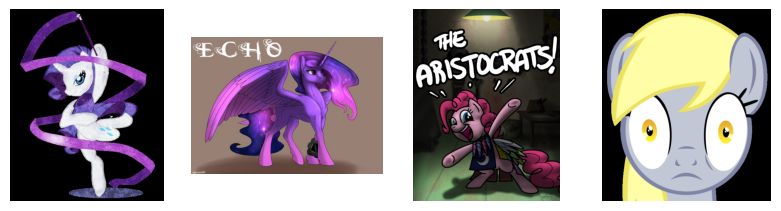

           rarity:  1.00  1.0
             horn:  1.00  1.0
          unicorn:  1.00  1.0
simple background:  0.65  1.0
          clothes:  0.58  0.0
      raised hoof:  0.56  0.0
           female:  0.51  1.0
              hat:  0.51  0.0
   looking at you:  0.51  0.0
          smiling:  0.51  0.0

          alicorn:  1.00  1.0
            wings:  0.84  1.0
          jewelry:  0.82  0.0
simple background:  0.80  1.0
             horn:  0.59  1.0
      raised hoof:  0.54  0.0
        ear fluff:  0.52  0.0
          smiling:  0.51  0.0
           female:  0.51  0.0
      chest fluff:  0.51  0.0
   looking at you:  0.51  0.0

       earth pony:  1.00  1.0
       pinkie pie:  1.00  1.0
       open mouth:  0.52  0.0
             male:  0.52  0.0
             foal:  0.51  0.0
           female:  0.50  1.0
          smiling:  0.50  0.0

       earth pony:  0.99  0.0
simple background:  0.90  1.0
          pegasus:  0.70  1.0
             foal:  0.54  0.0
          smiling:  0.50  0.0
       

In [ ]:
from utils import visualize
import numpy as np

np.random.seed(8)
idx_obs = np.random.choice(idx_test, 4)

rows = df.loc[idx_obs]

with torch.inference_mode():
    model.eval()

    logits = model(torch.tensor(ds.embeddings[idx_obs]).to(device))
    logits = sigmoid(logits)

    visualize(rows, logits.cpu().numpy(), to_predict)

In [ ]:
#ds = Horses(df, to_predict)

In [ ]:
#model = Tagger(model).to(device)